In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import seaborn.objects as so
import numpy as np
from lqg import xcorr
import arviz as az

from jax import random

plt.style.use("cppp.notebook")
theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.models.multisensory import MultisensoryDelayModel, UnisensoryDelayModel
from cppp.load import preprocess_multisensory_data, load_multisensory_data


## Load data

In [2]:

df = load_multisensory_data(base_path="../data")
df.head()

print(df["participant"].unique())

Multisensory DataFrame loaded from ../data/multisensory/df_all_phases_2participants.csv with shape: (52874, 10)
[765738475 802096684]


In [3]:
df.columns

Index(['participant', 'trial_number', 'phase', 'type', 'vis_noise',
       'cursor_offset', 'time', 'lefty_pos', 'righty_pos', 'cursory_pos'],
      dtype='object')

In [4]:
for condition in df["type"].unique():
    for vis_noise in df["vis_noise"].unique():
        print(condition, vis_noise)
        data = preprocess_multisensory_data(
                        df, participant=765738475, condition=condition, vis_noise=vis_noise
                    )
        print(data.shape)

vis 1
(8, 166, 2)
vis 2
(8, 166, 2)
prop 1
(8, 166, 2)
prop 2
(8, 166, 2)
multi 1
(8, 166, 2)
multi 2
(8, 166, 2)


## Plot some example trials

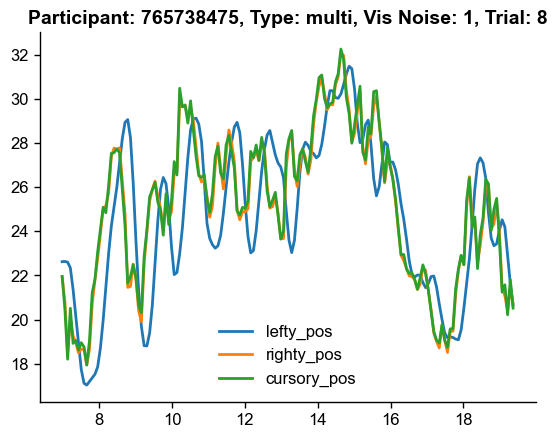

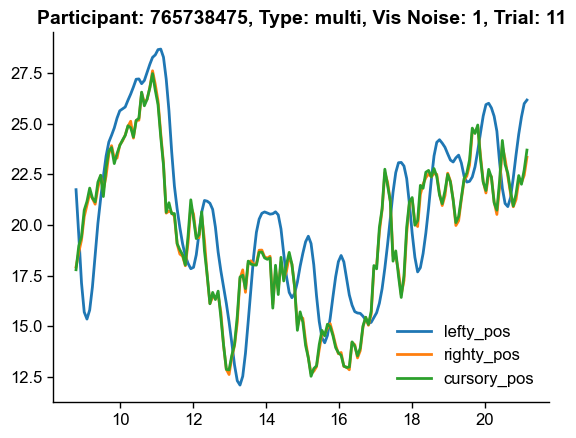

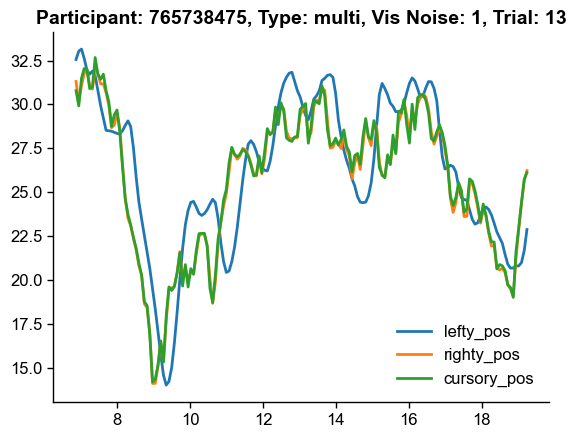

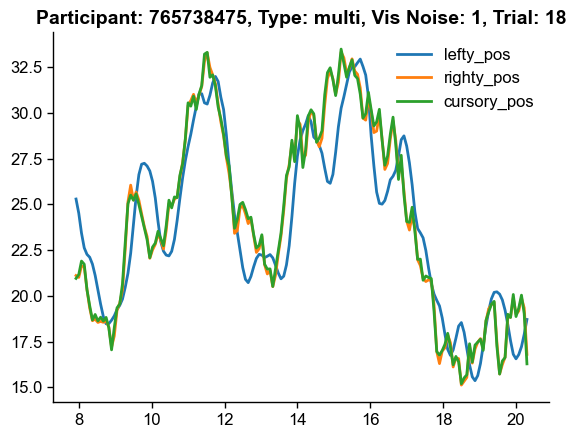

In [5]:
for i, (name, group) in enumerate(df.groupby(["participant", "type", "vis_noise", "trial_number"])):
    plt.plot(group["time"], group["lefty_pos"], label="lefty_pos")
    plt.plot(group["time"], group["righty_pos"], label="righty_pos")
    plt.plot(group["time"], group["cursory_pos"], label="cursory_pos")
    plt.title(f"Participant: {name[0]}, Type: {name[1]}, Vis Noise: {name[2]}, Trial: {name[3]}")
    plt.legend()
    plt.show()

    if i > 2:
        break

## Joint model

In [6]:
# participant = 765738475
# participant = 212056115
participant = 802096684
models = {model_name: az.from_netcdf(
                f"../results/multisensory-mcmc-{participant}_1_2_1_2500_2500_4_{model_name}.nc"
            )
            for model_name in ["optimal", "no_integration", "equal_integration"]}

# TODO: rhats

                   rank     elpd_loo     p_loo  elpd_diff   weight         se  \
no_integration        0 -3027.883354  1.331319   0.000000  0.86965  39.547556   
optimal               1 -3029.104774  1.330856   1.221419  0.00000  39.502001   
equal_integration     2 -3066.233406  2.207850  38.350052  0.13035  43.323517   

                         dse  warning scale  
no_integration      0.000000    False   log  
optimal             0.426950    False   log  
equal_integration  12.198978    False   log  
                   rank     elpd_loo     p_loo  elpd_diff        weight  \
no_integration        0 -3681.520503  2.868966   0.000000  1.000000e+00   
optimal               1 -3682.641380  2.868752   1.120877  3.025358e-15   
equal_integration     2 -3738.173151  4.434584  56.652648  1.332268e-15   

                          se        dse  warning scale  
no_integration     56.462837   0.000000    False   log  
optimal            56.312181   0.706001    False   log  
equal_integration  

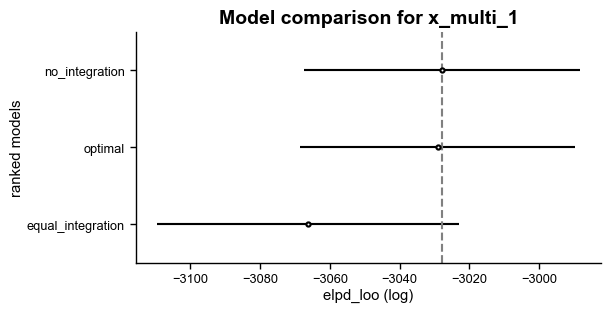

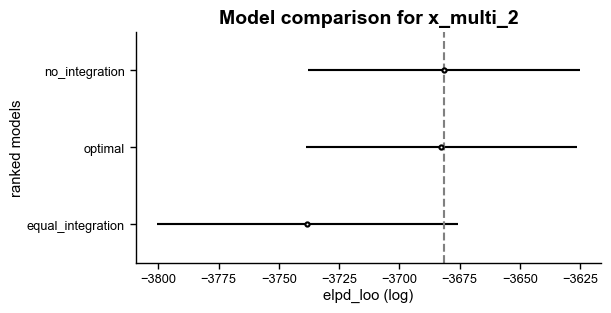

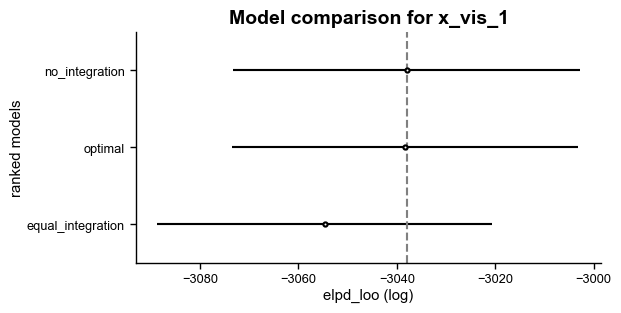

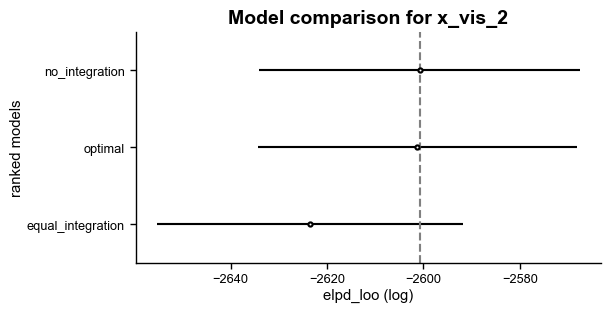

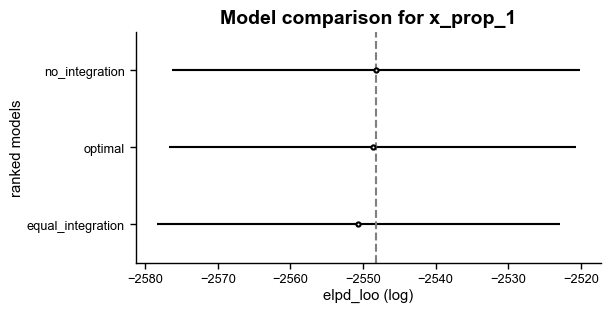

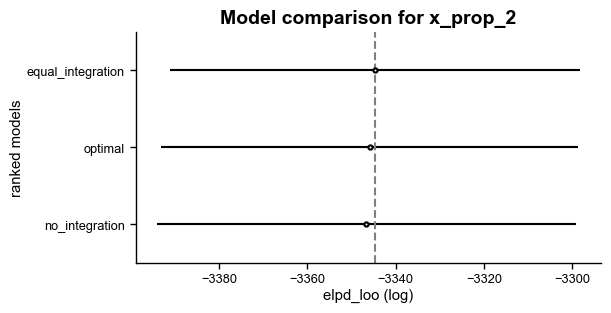

In [7]:
for var_name in ["x_multi_1", "x_multi_2", "x_vis_1", "x_vis_2", "x_prop_1", "x_prop_2"]:

    comp_df = az.compare(models, var_name=var_name)
    print(comp_df)
    axes = az.plot_compare(comp_df=comp_df)
    axes.set_title(f"Model comparison for {var_name}")

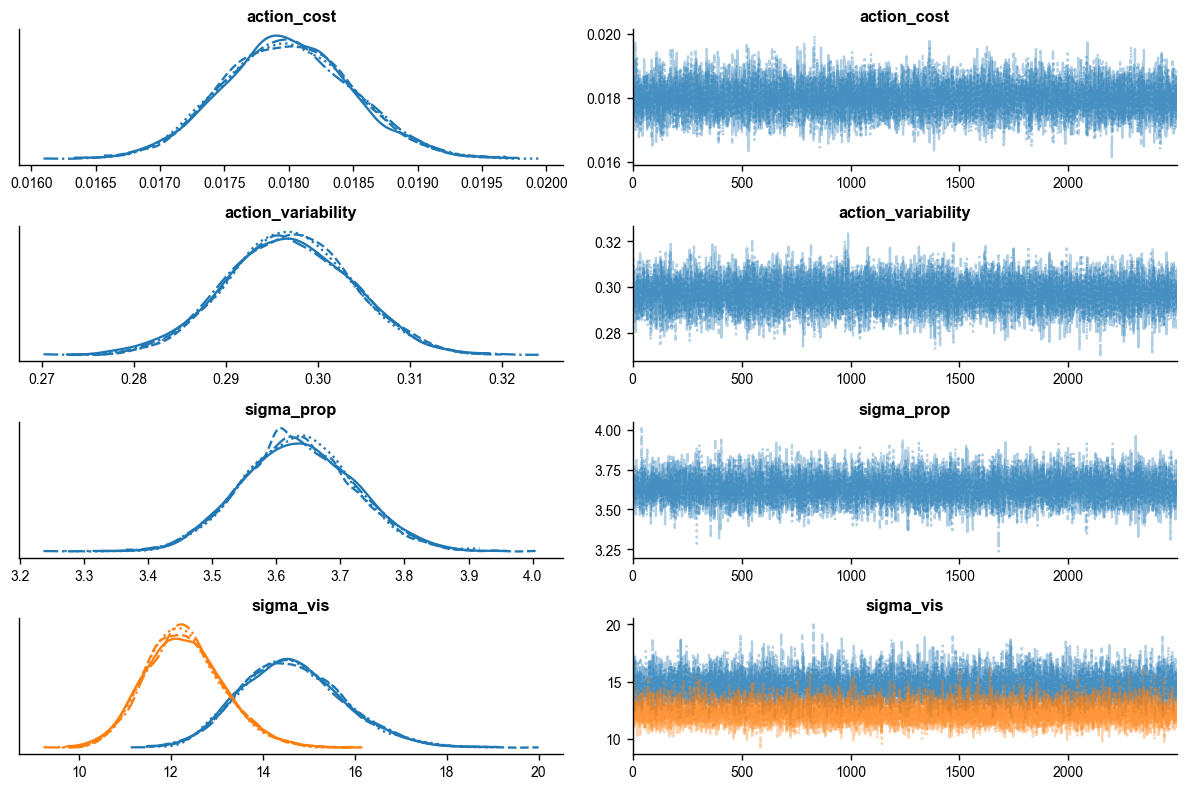

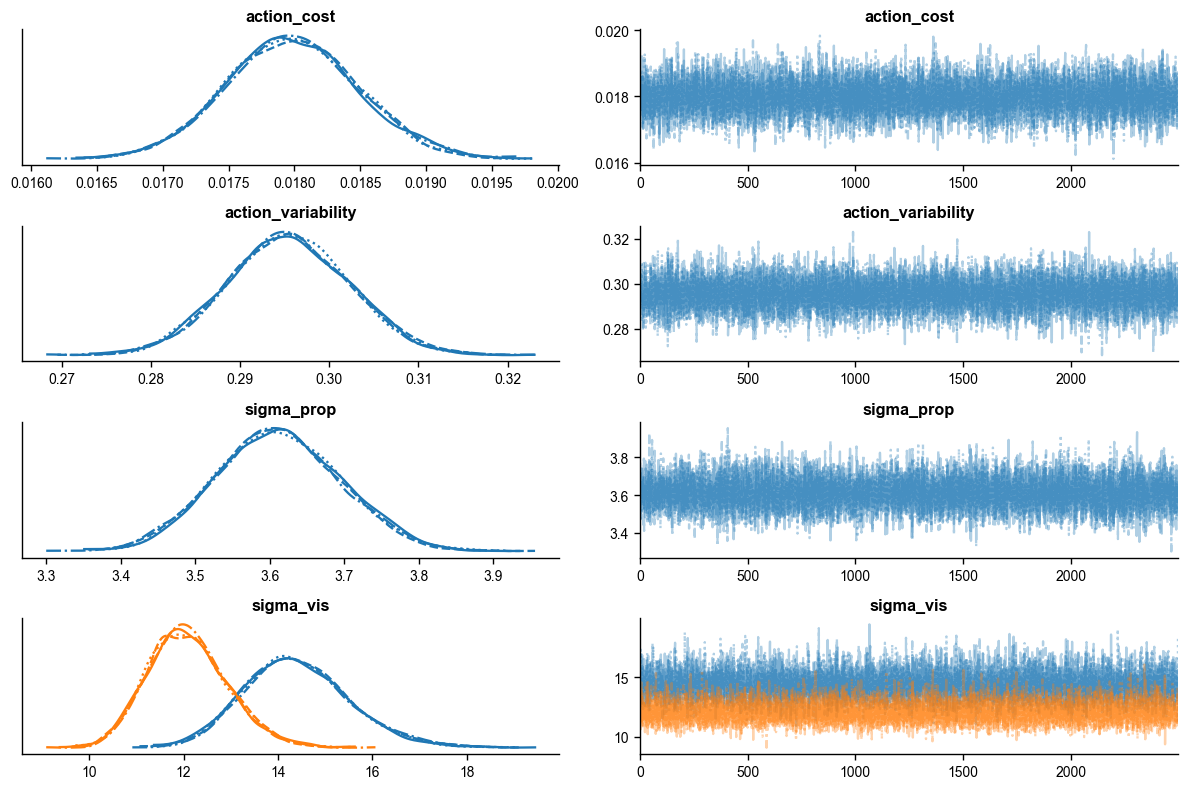

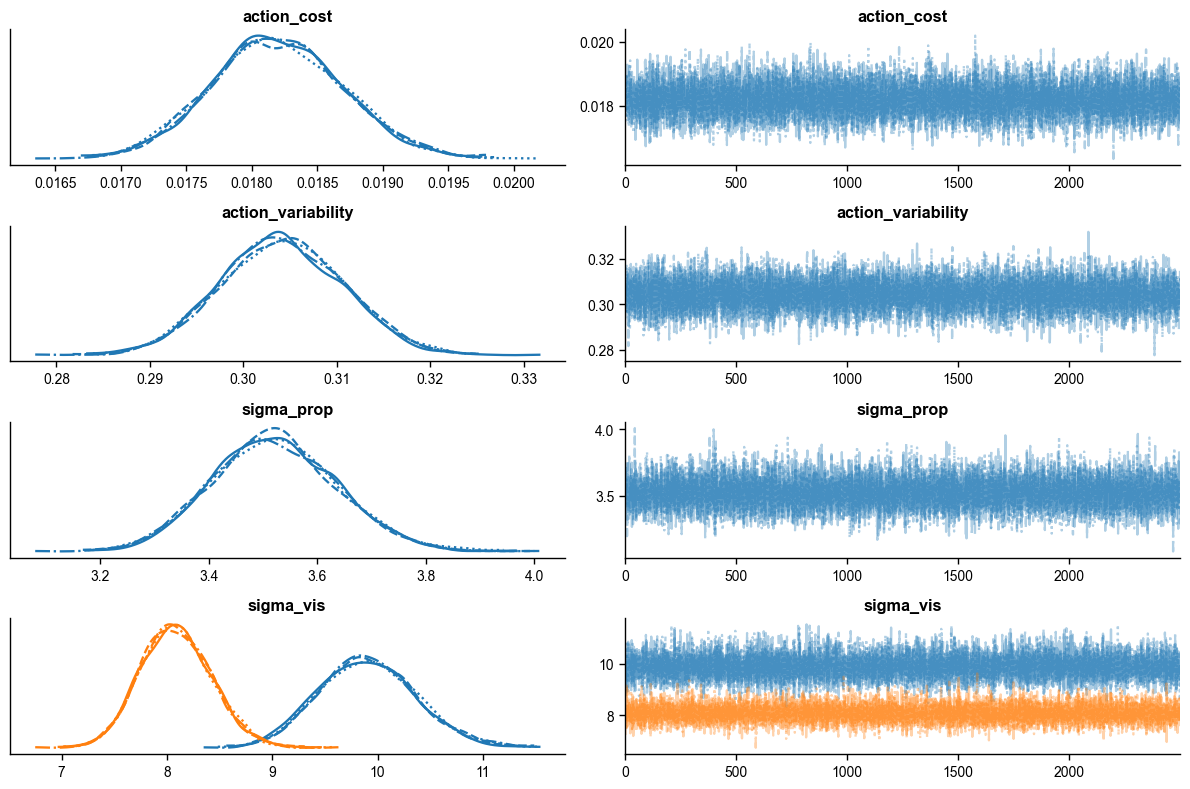

In [8]:
for name, model in models.items():
    az.plot_trace(model)
    plt.tight_layout()

Condition: multi, Vis Noise: 1
{'action_cost': 0.018, 'action_variability': 0.297, 'sigma_prop': 3.634, 'sigma_vis[0]': 14.652, 'sigma_vis[1]': 12.297}


Condition: multi, Vis Noise: 2
{'action_cost': 0.018, 'action_variability': 0.297, 'sigma_prop': 3.634, 'sigma_vis[0]': 14.652, 'sigma_vis[1]': 12.297}
Condition: vis, Vis Noise: 1
{'action_cost': 0.018, 'action_variability': 0.297, 'sigma_prop': 3.634, 'sigma_vis[0]': 14.652, 'sigma_vis[1]': 12.297}
Condition: vis, Vis Noise: 2
{'action_cost': 0.018, 'action_variability': 0.297, 'sigma_prop': 3.634, 'sigma_vis[0]': 14.652, 'sigma_vis[1]': 12.297}
Condition: prop, Vis Noise: 1
{'action_cost': 0.018, 'action_variability': 0.297, 'sigma_prop': 3.634, 'sigma_vis[0]': 14.652, 'sigma_vis[1]': 12.297}
Condition: prop, Vis Noise: 2
{'action_cost': 0.018, 'action_variability': 0.297, 'sigma_prop': 3.634, 'sigma_vis[0]': 14.652, 'sigma_vis[1]': 12.297}
Condition: multi, Vis Noise: 1
{'action_cost': 0.018, 'action_variability': 0.295, 'sigma_prop': 3.611, 'sigma_vis[0]': 14.401, 'sigma_vis[1]': 12.095}
Condition: multi, Vis Noise: 2
{'action_cost': 0.018, 'action_variability': 0.295, 'sigma_prop

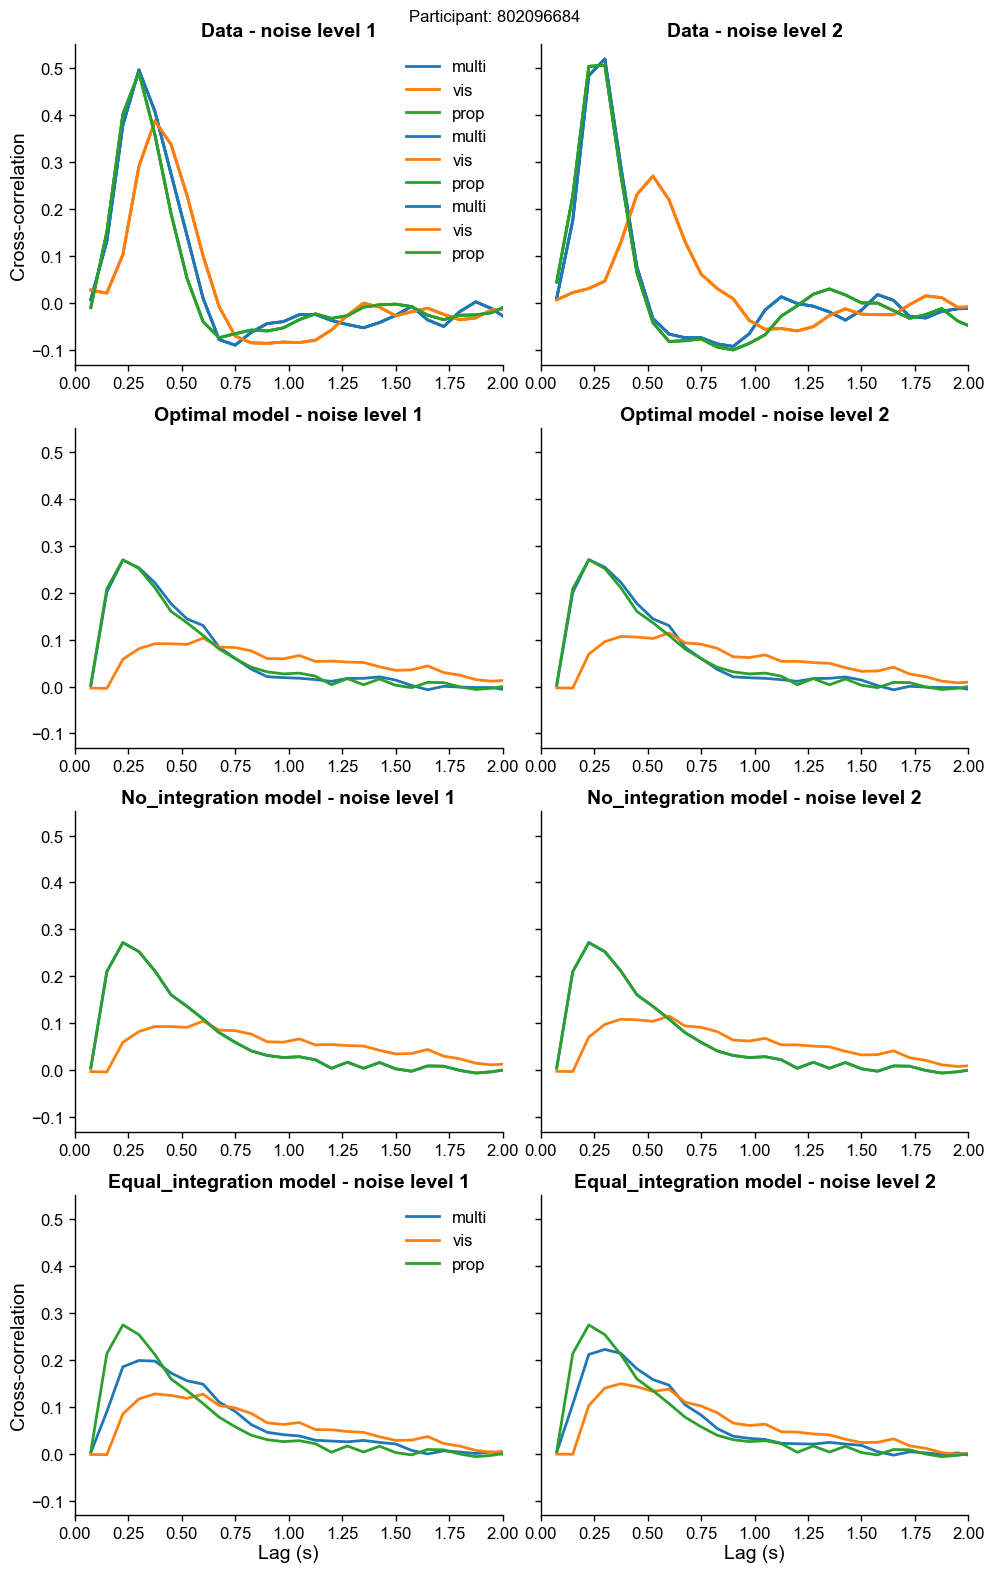

In [9]:
import jax.numpy as jnp

delays = {"prop": 1, "vis": 2}

f, ax = plt.subplots(4, 2, figsize=(10, 16), sharey=True)

for k, (model_name, model) in enumerate(models.items()):
    summary = az.summary(model)
    # get posterior mean
    posterior_mean = summary["mean"].to_dict()
    for i, condition in enumerate(["multi", "vis", "prop"]):

        for j, vis_noise in enumerate([1, 2]):
            # preprocess the data for this participant, condition, and noise level
            data = preprocess_multisensory_data(
                    df, participant=participant, condition=condition, vis_noise=vis_noise
                )

            
            print(f"Condition: {condition}, Vis Noise: {vis_noise}")
            print(posterior_mean)

            # create model with posterior mean parameters (note that we have to rename the sigmas parameters for the multisensory model)
            if condition == "multi":
                if model_name == "optimal":
                    model = MultisensoryDelayModel(
                        process_noise=1.2,
                        sigmas=[posterior_mean["sigma_prop"], posterior_mean[f"sigma_vis[{vis_noise - 1}]"]],
                        action_variability=posterior_mean["action_variability"],
                        action_cost=posterior_mean["action_cost"],
                        delays=[delays["prop"], delays["vis"]],
                        dt=0.075,
                        T=data.shape[1],
                    )
                elif model_name == "no_integration":
                    model = UnisensoryDelayModel(
                        process_noise=1.2,
                        sigma=posterior_mean[f"sigma_prop"],
                        action_variability=posterior_mean["action_variability"],
                        action_cost=posterior_mean["action_cost"],
                        delay=delays["prop"],
                        dt=0.075,
                        T=data.shape[1],
                    )
                elif model_name == "equal_integration":
                    sigma = jnp.sqrt((posterior_mean[f"sigma_prop"] ** 2 + posterior_mean[f"sigma_vis[{vis_noise - 1}]"] ** 2) / 2)
                    model = MultisensoryDelayModel(
                        process_noise=1.2,
                        sigmas=[sigma, sigma],
                        action_variability=posterior_mean["action_variability"],
                        action_cost=posterior_mean["action_cost"],
                        delays=[delays["prop"], delays["vis"]],
                        dt=0.075,
                        T=data.shape[1],
                    )
            else:
                delay = delays[condition]
                model = UnisensoryDelayModel(
                    process_noise=1.2,
                    sigma=posterior_mean[f"sigma_{condition}"] if condition == "prop" else posterior_mean[f"sigma_vis[{vis_noise - 1}]"],
                    action_variability=posterior_mean["action_variability"],
                    action_cost=posterior_mean["action_cost"],
                    delay=delay,
                    dt=0.075,
                    T=data.shape[1],
                )

            # TODO: generate prediction for multisensory condition from unisensory model fits

            # simulate data from the model and compute cross-correlation of velocities for both the simulated data and the real data
            sim_data = model.simulate(rng_key=random.PRNGKey(0), n=100)
            sim_vels = np.diff(sim_data, axis=1)
            lags, sim_correls = xcorr(sim_vels[:, :, 1], sim_vels[:, :, 0], maxlags=50)

            
            vels = np.diff(data, axis=1)
            lags, correls = xcorr(vels[:, :, 1], vels[:, :, 0], maxlags=50)

            # plot the cross-correlations for the real data and the simulated data
            ax[0, j].plot(
                lags[51:] * 0.075, correls.mean(axis=0)[51:], label=f"{condition}", color=f"C{i}"
            )
            ax[k+1, j].plot(
                lags[51:] * 0.075, sim_correls.mean(axis=0)[51:], label=f"{condition}", color=f"C{i}"
            )

            ax[0, j].set_xlim(0, 2)
            ax[k+1, j].set_xlim(0, 2)

            ax[0, j].set_title(f"Data - noise level {vis_noise}")
            ax[k+1, j].set_title(f"{model_name.capitalize()} model - noise level {vis_noise}")

ax[k+1, 0].set_xlabel("Lag (s)")
ax[k+1, 1].set_xlabel("Lag (s)")
ax[0, 0].set_ylabel("Cross-correlation")
ax[k+1, 0].set_ylabel("Cross-correlation")

ax[0, 0].legend()
ax[k+1, 0].legend()
f.suptitle(f"Participant: {participant}")
f.tight_layout()